# 5. Global flood hazard (GLOFAS)

Alongside the *historic* flood maps, `hazard(...)` queries the modelled **CEMS-GLOFAS**
flood-hazard maps by **return period** (the depth expected on average once every N years).
Hazard catalogues are just as *actionable* as historic ones — the same `.download()`,
`.stats()`, `.plot()`, and `.explore()` all work.

> This tutorial downloads real hazard tiles, so it needs network access.

In [1]:
from pathlib import Path

import euroflood as ef

ef.settings.output_dir = Path("out")

Query the 100- and 500-year return periods for Zutphen. One row per return period (supported:
10, 20, 50, 75, 100, 200, 500):

In [2]:
haz = ef.hazard("Zutphen, Netherlands", return_period=[100, 500], shape="bbox")
haz

,collection,return_period,model_version,n_tiles,filename,area_km2,geometry,path
0,hazard,100,v2.1.2,1,hazard_RP100.tif,83.144,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/hazard_RP100_8277ba1c.tif
1,hazard,500,v2.1.2,1,hazard_RP500.tif,83.144,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/hazard_RP500_8277ba1c.tif


Download and measure them. GLOFAS depth is already in **metres** and is reported as-is (EFAS
historic depth is centimetres; the scale is chosen automatically per catalogue).

In [3]:
haz = haz.download()
haz.stats()

,return_period,wet_pixels,max_depth_m,mean_depth_m,p95_depth_m,flooded_area_km2,volume_m3,volume_Mm3
0,100,13558,5.752,2.213,4.017,80.0169,177115974.3,177.1160
1,500,13823,6.139,2.548,4.384,81.5809,207891205.5,207.8912


## Static and interactive depth maps

Render the 100-year hazard depth as a static image…

<Axes: title={'center': 'Flood depth — hazard_RP100_8277ba1c'}>

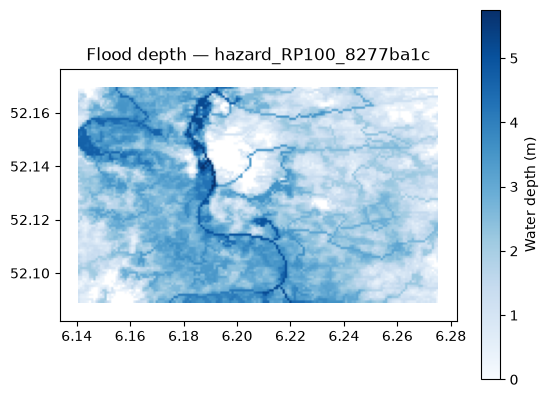

In [4]:
rp100 = haz[haz["return_period"] == 100]
rp100.plot(depth=True)

…and as an interactive folium overlay you can pan and zoom:


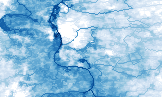

In [5]:
rp100.explore(depth=True, tiles="grayscale")

The recurrence/footprint views are historic-only (hazard has no event index), so a hazard
`.explore()` without `depth=` shows a context map of the queried area:

In [6]:
haz.explore(tiles="grayscale")